<a href="https://colab.research.google.com/github/Skhelshiaty/CS-3072-Data-Science/blob/main/SeifFinalExamDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# =========================
# Question 4 - Data Science Practical
# Dataset: psyco.csv
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

#Step 1: Upload the dataset

In [4]:
from google.colab import files
uploaded = files.upload()

Saving psyco(1).csv to psyco(1).csv


#Step 2: Check the exact uploaded file name

In [5]:
import os
os.listdir()



['.config', 'psyco(1).csv', 'sample_data']

In [9]:
import pandas as pd

df = pd.read_csv("psyco(1).csv")
df.head()

,age,gender,occupation,line_of_work,time_bp,time_dp,travel_time,easeof_online,home_env,prod_inc,...,fam_connect,relaxed,self_time,like_hw,dislike_hw,prefer,certaindays_hw,Unnamed: 19,time_bp.1,travel+work
0,19-25,Male,Student in College,NaN,7,5,0.5,3,3,0.0,...,1.0,-0.5,-0.5,100,1,Complete Physical Attendance,Yes,NaN,7,NaN
1,Dec-18,Male,Student in School,NaN,7,11,0.5,4,2,-0.5,...,1.0,1.0,1.0,1111,1110,Complete Physical Attendance,No,NaN,7,NaN
2,19-25,Male,Student in College,NaN,7,7,1.5,2,2,1.0,...,0.5,0.5,0.5,1100,111,Complete Physical Attendance,Yes,NaN,7,NaN
3,19-25,Male,Student in College,NaN,7,7,1.5,3,1,0.0,...,0.0,-1.0,-0.5,100,1111,Complete Physical Attendance,Yes,NaN,7,NaN
4,19-25,Female,Student in College,NaN,7,7,1.5,2,2,0.0,...,0.0,0.5,0.0,1010,1000,Complete Physical Attendance,Yes,NaN,7,NaN


In [11]:
df[['age', 'prod_inc']].head(15)

,age,prod_inc
0,19-25,0.0
1,Dec-18,-0.5
2,19-25,1.0
3,19-25,0.0
4,19-25,0.0
5,19-25,-1.0
6,19-25,0.5
7,19-25,0.0
8,19-25,1.0
9,19-25,0.0


In [12]:
df['age'].value_counts()

,count
age,
19-25,345
26-32,261
40-50,181
50-60,170
33-40,102
Dec-18,74
60+,42


In [13]:
df['prod_inc'].value_counts()

,count
prod_inc,
0.5,302
0.0,295
-0.5,279
-1.0,150
1.0,149


##Cleaning cell

In [14]:
print("Before cleaning:", df.shape)

# 1. Remove unnamed useless columns
df = df.loc[:, ~df.columns.str.contains("Unnamed")]

# 2. Remove exact duplicate rows
df = df.drop_duplicates()

# 3. Fix age column problem
# Excel may convert "10-18" into dates like "Dec-18"
age_fix = {
    "Dec-18": "12-18",
    "Dec 18": "12-18",
    "19-\n25": "19-25"
}

df["age"] = df["age"].replace(age_fix)
df["age"] = df["age"].astype(str).str.replace("\n", "", regex=False).str.strip()

# 4. Keep prod_inc negative values
# Negative values are not automatically errors because this dataset appears to use a scale
# such as -1, -0.5, 0, 0.5, 1.
# So we do NOT remove them.

# 5. Fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("After cleaning:", df.shape)
print(df.isnull().sum())

Before cleaning: (1175, 22)
After cleaning: (413, 21)
age                 0
gender              0
occupation          0
line_of_work        0
time_bp             0
time_dp             0
travel_time         0
easeof_online       0
home_env            0
prod_inc            0
sleep_bal           0
new_skill           0
fam_connect         0
relaxed             0
self_time           0
like_hw             0
dislike_hw          0
prefer              0
certaindays_hw      0
time_bp.1           0
travel+work       413
dtype: int64


##Step 3: Data Cleaning

The dataset contained some formatting and missing-value issues.  
The `Unnamed` column was removed because it did not contain useful information.  
Duplicate rows were checked and removed to avoid repeated records affecting the analysis.

The `age` column had formatting problems because some age ranges appeared incorrectly, such as `Dec-18`, which likely resulted from spreadsheet auto-formatting. This value was corrected to `12-18`, and line breaks in age ranges were removed.

The negative values in `prod_inc` were kept because they appear to represent a rating scale rather than incorrect data. Since the scale includes values such as -1, -0.5, 0, 0.5, and 1, removing them would incorrectly change the meaning of the dataset.

Missing numerical values were filled using the median, while missing categorical values were filled using the mode.

In [15]:
df[['age', 'prod_inc']].head(15)

,age,prod_inc
0,19-25,0.0
1,12-18,-0.5
2,19-25,1.0
3,19-25,0.0
4,19-25,0.0
5,19-25,-1.0
6,19-25,0.5
7,19-25,0.0
8,19-25,1.0
9,19-25,0.0


The `prod_inc` feature contains negative and positive scaled values, indicating an ordinal/rating measure rather than actual income. Therefore, negative values were retained as valid responses.

The age group `33-40` appeared with low frequency. It was retained because it represents a valid respondent category and preserves dataset diversity.

In [16]:
df['age'].value_counts()

,count
age,
19-25,233
12-18,51
26-32,38
40-50,33
50-60,27
33-40,24
60+,7


In [17]:
df['prod_inc'].value_counts().sort_index()

,count
prod_inc,
-1.0,58
-0.5,104
0.0,145
0.5,74
1.0,32


#Step 4: EDA plots

##1. Age Group Plot

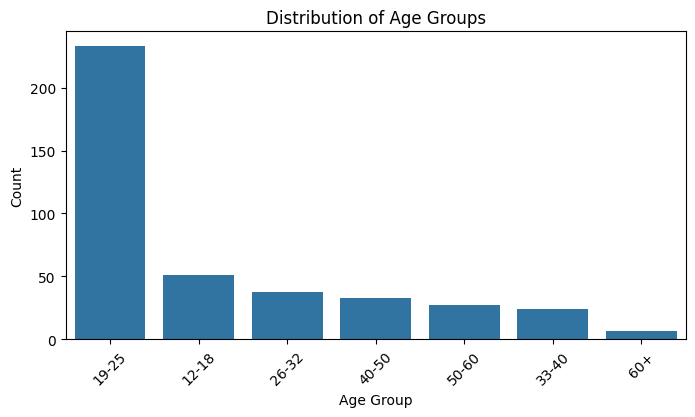

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.countplot(data=df, x='age', order=df['age'].value_counts().index)
plt.title("Distribution of Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Gender Plot

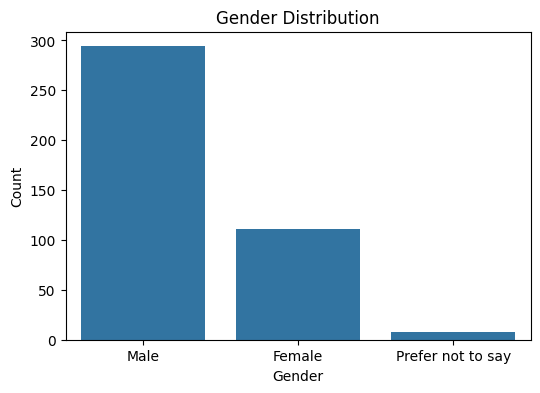

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

##3. prod_inc Plot

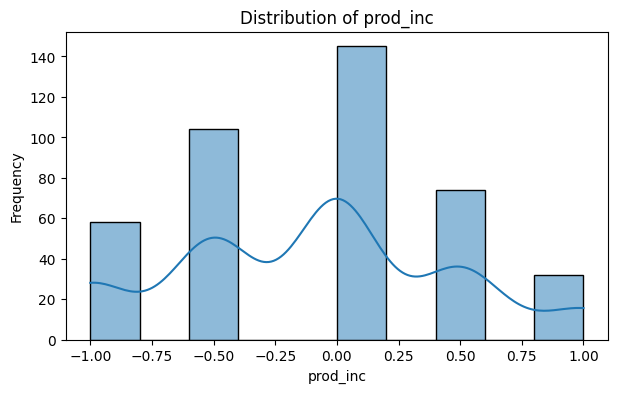

In [20]:
plt.figure(figsize=(7,4))
sns.histplot(df['prod_inc'], bins=10, kde=True)
plt.title("Distribution of prod_inc")
plt.xlabel("prod_inc")
plt.ylabel("Frequency")
plt.show()

##4. Heatmap (very good mark)

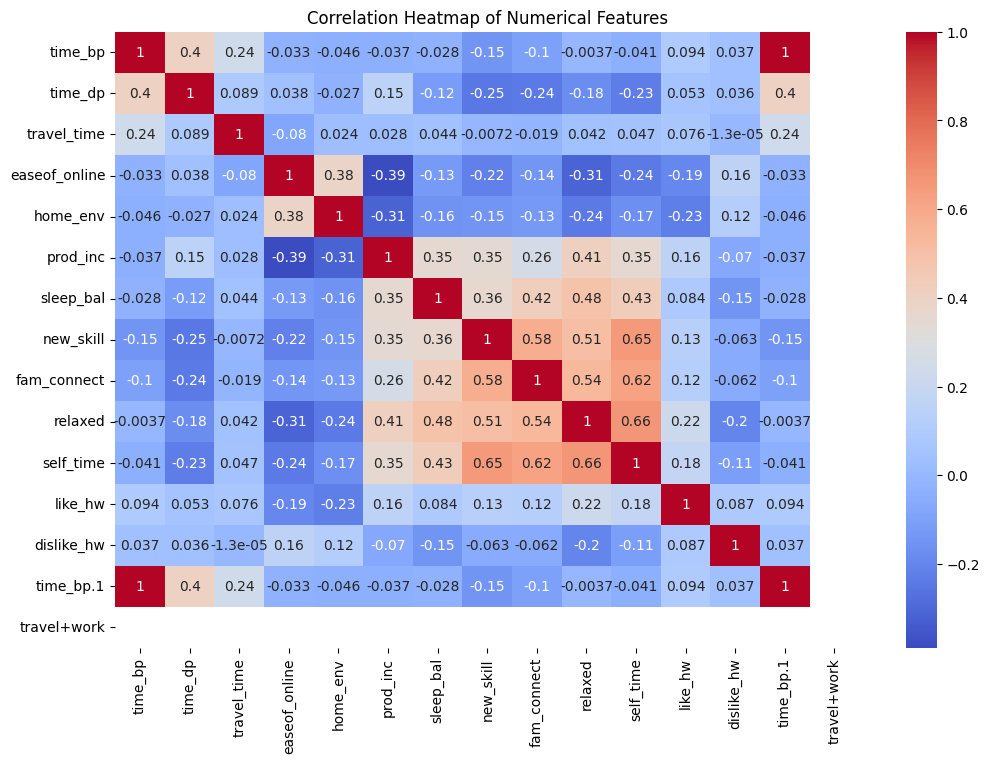

In [21]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## Specific Insights from the Visualizations

### Age Distribution
- The **19–25** age group is the largest category by a wide margin, indicating that most respondents are young adults or college-age participants.
- The **12–18** group is the second largest, while older age groups such as **60+** have very few responses.
- This suggests the dataset is more representative of younger individuals than older populations.

### Gender Distribution
- **Male respondents** form the majority of the sample.
- **Female respondents** are the second largest group.
- Only a very small number selected **Prefer not to say**.
- This indicates some gender imbalance in the dataset.

### Production Income (`prod_inc`) Distribution
- Most values are concentrated around **0** and **-0.5**, suggesting many respondents gave neutral or slightly negative ratings.
- Fewer responses appear at the extreme values **-1** and **1**.
- This indicates moderate responses were more common than extreme opinions.

### Correlation Heatmap
- `relaxed` and `self_time` show a **strong positive correlation (~0.66)**, meaning respondents with more personal time also tend to feel more relaxed.
- `new_skill` and `self_time` have a **positive correlation (~0.65)**, suggesting more available time may support learning new skills.
- `fam_connect` and `self_time` also show a positive relationship (~0.62).
- `easeof_online` and `prod_inc` show a **negative correlation (~-0.39)**, indicating an inverse relationship between these variables.
- `time_bp` and `time_bp.1` have a perfect correlation (**1.00**), suggesting one column is duplicated.

#Step 5: Normalization

In [22]:
from sklearn.preprocessing import MinMaxScaler

num_cols = df.select_dtypes(include=['int64','float64']).columns

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df[num_cols].head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


,time_bp,time_dp,travel_time,easeof_online,home_env,prod_inc,sleep_bal,new_skill,fam_connect,relaxed,self_time,like_hw,dislike_hw,time_bp.1,travel+work
0,0.375,0.125,0.0,0.50,0.50,0.50,0.50,0.75,1.00,0.25,0.25,0.089189,0.000000,0.375,NaN
1,0.375,0.875,0.0,0.75,0.25,0.25,0.75,0.00,1.00,1.00,1.00,1.000000,0.999099,0.375,NaN
2,0.375,0.375,0.4,0.25,0.25,1.00,0.50,0.75,0.75,0.75,0.75,0.990090,0.099099,0.375,NaN
3,0.375,0.375,0.4,0.50,0.00,0.50,1.00,0.75,0.50,0.00,0.25,0.089189,1.000000,0.375,NaN
4,0.375,0.375,0.4,0.25,0.25,0.50,0.50,0.50,0.50,0.75,0.50,0.909009,0.900000,0.375,NaN


## Normalization Results

- Min-Max normalization was successfully applied to the numerical features.
- All transformed numerical values were scaled into the range **0 to 1**, improving comparability between variables with different original scales.
- Features such as `time_bp`, `time_dp`, `travel_time`, and `prod_inc` were successfully normalized.

### Note
- The column `travel+work` returned `NaN` values during scaling because it contains missing or invalid values only.
- Since this column does not provide useful numeric information, it can be excluded from modeling or further cleaned.

##Step 1: Drop column

In [23]:
df = df.drop(columns=['travel+work'], errors='ignore')

##Step 2: Run classifier

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Copy dataset
model_df = df.copy()

# Encode categorical columns
for col in model_df.select_dtypes(include='object').columns:
    model_df[col] = LabelEncoder().fit_transform(model_df[col])

# Target variable
X = model_df.drop('prefer', axis=1)
y = model_df['prefer']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))

Accuracy: 0.7590361445783133

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.90      0.85        62
           1       0.54      0.33      0.41        21

    accuracy                           0.76        83
   macro avg       0.67      0.62      0.63        83
weighted avg       0.73      0.76      0.74        83


Confusion Matrix:
 [[56  6]
 [14  7]]


## Bonus Classifier Results

A Random Forest classifier was applied to predict the `prefer` variable.

### Model Performance
- Accuracy achieved: **75.9%**
- Class `0` was predicted more effectively with high recall (**0.90**).
- Class `1` had lower recall (**0.33**), indicating fewer correct predictions for the minority class.

### Confusion Matrix
- 56 records were correctly predicted as Class 0.
- 7 records were correctly predicted as Class 1.
- Some misclassification occurred between the two classes.

### Justification of Model Choice
Random Forest was selected because it handles structured datasets well, works with mixed features, and reduces overfitting through multiple decision trees.

#Step 6: What, Why, and How Framework

### What
The visualizations included bar charts for age and gender distributions, a histogram for `prod_inc`, and a heatmap for numerical correlations.

### Why
These charts were selected because bar charts clearly compare category frequencies, histograms show the spread of numerical values, and heatmaps reveal relationships between multiple variables at once.

### How
The age chart highlighted that the 19–25 group dominates the sample.  
The gender chart showed males were the largest category.  
The histogram showed most `prod_inc` responses cluster near neutral values.  
The heatmap made strong positive and negative correlations easy to identify using color intensity.

### Effectiveness
The selected visuals are simple, readable, and effective for quickly understanding patterns in the dataset.

### Suggested Improvement
Pie charts, boxplots, or grouped bar charts could provide additional comparisons across categories.

## References

1. McKinney, W. *Python for Data Analysis*. O’Reilly Media, 2022.  
2. Pandas Documentation. https://pandas.pydata.org/  
3. Matplotlib Documentation. https://matplotlib.org/  
4. Seaborn Documentation. https://seaborn.pydata.org/  
5. Scikit-learn Documentation. https://scikit-learn.org/